<a href="https://colab.research.google.com/github/dadakhalander/KPI/blob/main/Confectionary.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# STEP 1: INSTALL REQUIRED LIBRARIES
!pip install pandas openpyxl plotly missingno --quiet

In [2]:
# STEP 2: IMPORT LIBRARIES
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import missingno as msno
import matplotlib.pyplot as plt

# Plot settings
plt.rcParams['figure.figsize'] = (12,6)


In [3]:
# STEP 3: LOAD EXCEL FILE
excel_file = "Confectionary_[4564].xlsx"

In [4]:
# Check workbook sheets
xls = pd.ExcelFile(excel_file)
print("Available Sheets:", xls.sheet_names)

Available Sheets: ['Sheet1']


In [5]:
# Load primary sheet
df = pd.read_excel(excel_file, sheet_name=xls.sheet_names[0])

In [6]:
# Preview data
print("\nFirst 5 Rows:")
display(df.head())


First 5 Rows:


,Date,Country(UK),Confectionary,Units Sold,Cost(£),Profit(£),Revenue(£)
0,2002-11-11,England,Biscuit,1118.0,2459.6,3130.4,749954.4
1,2002-07-05,England,Biscuit,708.0,1557.6,1982.4,300758.4
2,2001-10-31,England,Biscuit,1269.0,2791.8,3553.2,966216.6
3,2004-09-13,England,Biscuit,1631.0,3588.2,4566.8,1596096.6
4,2004-03-10,England,Biscuit,2240.0,4928.0,6272.0,3010560.0


In [7]:
# STEP 4: DATA UNDERSTANDING

print("Dataset Shape:", df.shape)
print("\nDataset Info:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDescriptive Statistics:")
display(df.describe(include='all'))

Dataset Shape: (1001, 7)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           1001 non-null   datetime64[ns]
 1   Country(UK)    1001 non-null   object        
 2   Confectionary  1001 non-null   object        
 3   Units Sold     996 non-null    float64       
 4   Cost(£)        992 non-null    float64       
 5   Profit(£)      998 non-null    float64       
 6   Revenue(£)     1001 non-null   float64       
dtypes: datetime64[ns](1), float64(4), object(2)
memory usage: 54.9+ KB

Missing Values:
Date             0
Country(UK)      0
Confectionary    0
Units Sold       5
Cost(£)          9
Profit(£)        3
Revenue(£)       0
dtype: int64

Descriptive Statistics:


,Date,Country(UK),Confectionary,Units Sold,Cost(£),Profit(£),Revenue(£)
count,1001,1001,1001,996.000000,992.000000,998.000000,1.001000e+03
unique,NaN,5,8,NaN,NaN,NaN,NaN
top,NaN,Scotland,Caramel,NaN,NaN,NaN,NaN
freq,NaN,210,345,NaN,NaN,NaN,NaN
mean,2002-11-19 10:54:32.727272832,NaN,NaN,1633.360442,2820.190877,4012.076052,2.519449e+06
min,2000-01-02 00:00:00,NaN,NaN,200.000000,40.000000,160.000000,-2.196226e+07
25%,2001-05-12 00:00:00,NaN,NaN,923.000000,1204.000000,1872.400000,5.762400e+05
50%,2002-11-10 00:00:00,NaN,NaN,1530.500000,2456.800000,3459.000000,1.627208e+06
75%,2004-04-25 00:00:00,NaN,NaN,2300.000000,3977.625000,5445.000000,3.551112e+06
max,2005-12-28 00:00:00,NaN,NaN,4493.000000,10994.500000,13479.000000,2.018705e+07


In [8]:
# STEP 5: DATA CLEANING

# Rename columns for easier coding
df.columns = [
    'Date',
    'Country',
    'Confectionary',
    'Units_Sold',
    'Cost',
    'Profit',
    'Revenue'
]

In [9]:
# Convert date
df['Date'] = pd.to_datetime(df['Date'])

In [10]:
# Fill missing values
df['Units_Sold'].fillna(df['Units_Sold'].median(), inplace=True)
df['Cost'].fillna(df['Cost'].median(), inplace=True)
df['Profit'].fillna(df['Profit'].median(), inplace=True)

/tmp/ipykernel_7203/1169306122.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Units_Sold'].fillna(df['Units_Sold'].median(), inplace=True)
/tmp/ipykernel_7203/1169306122.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpl

In [11]:
# Feature Engineering
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month_name()
df['Month_Num'] = df['Date'].dt.month
df['Quarter'] = df['Date'].dt.quarter
df['Profit_Margin'] = (df['Profit'] / df['Revenue']) * 100

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           1001 non-null   datetime64[ns]
 1   Country        1001 non-null   object        
 2   Confectionary  1001 non-null   object        
 3   Units_Sold     1001 non-null   float64       
 4   Cost           1001 non-null   float64       
 5   Profit         1001 non-null   float64       
 6   Revenue        1001 non-null   float64       
 7   Year           1001 non-null   int32         
 8   Month          1001 non-null   object        
 9   Month_Num      1001 non-null   int32         
 10  Quarter        1001 non-null   int32         
 11  Profit_Margin  1001 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int32(3), object(3)
memory usage: 82.2+ KB


In [13]:
# Sort month order
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

print("\nCleaned Dataset Preview:")
display(df.head())


Cleaned Dataset Preview:


,Date,Country,Confectionary,Units_Sold,Cost,Profit,Revenue,Year,Month,Month_Num,Quarter,Profit_Margin
0,2002-11-11,England,Biscuit,1118.0,2459.6,3130.4,749954.4,2002,November,11,4,0.417412
1,2002-07-05,England,Biscuit,708.0,1557.6,1982.4,300758.4,2002,July,7,3,0.659134
2,2001-10-31,England,Biscuit,1269.0,2791.8,3553.2,966216.6,2001,October,10,4,0.367744
3,2004-09-13,England,Biscuit,1631.0,3588.2,4566.8,1596096.6,2004,September,9,3,0.286123
4,2004-03-10,England,Biscuit,2240.0,4928.0,6272.0,3010560.0,2004,March,3,1,0.208333


Missing Data Matrix:


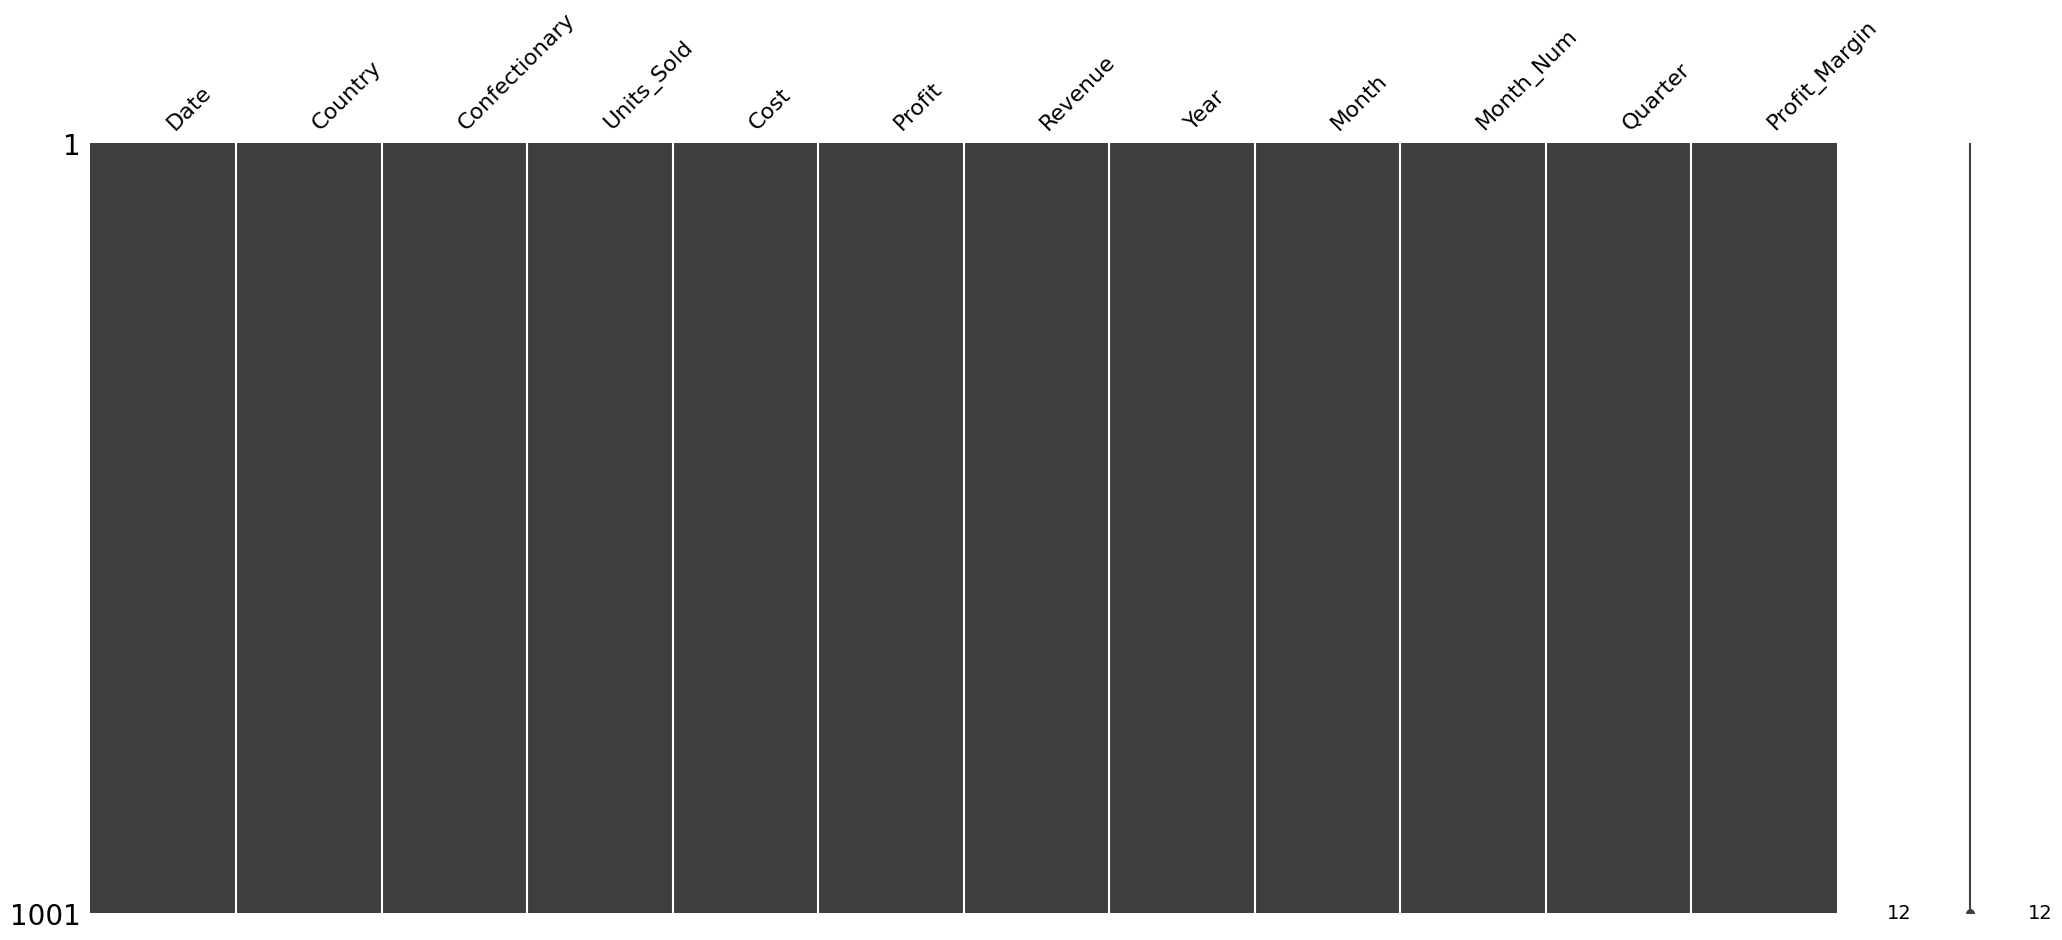

In [14]:
# STEP 6: MISSING VALUES VISUALIZATION

print("Missing Data Matrix:")
msno.matrix(df)
plt.show()

In [15]:
# STEP 7: UNIVARIATE ANALYSIS

# Revenue Distribution
fig = px.histogram(
    df,
    x='Revenue',
    nbins=40,
    title='Revenue Distribution',
    marginal='box'
)
fig.show()

# Profit Distribution
fig = px.histogram(
    df,
    x='Profit',
    nbins=40,
    title='Profit Distribution',
    marginal='box',
    color_discrete_sequence=['green']
)
fig.show()

# Units Sold Distribution
fig = px.histogram(
    df,
    x='Units_Sold',
    nbins=40,
    title='Units Sold Distribution',
    marginal='violin'
)
fig.show()

In [16]:
# STEP 8: CATEGORY ANALYSIS

country_rev = df.groupby('Country')['Revenue'].sum().reset_index()

fig = px.bar(
    country_rev,
    x='Country',
    y='Revenue',
    title='Total Revenue by Country',
    color='Revenue',
    text_auto=True
)
fig.show()

# Profit by Country
country_profit = df.groupby('Country')['Profit'].sum().reset_index()

fig = px.bar(
    country_profit,
    x='Country',
    y='Profit',
    title='Total Profit by Country',
    color='Profit',
    text_auto=True
)
fig.show()

# Revenue by Product
product_rev = df.groupby('Confectionary')['Revenue'].sum().reset_index()

fig = px.pie(
    product_rev,
    names='Confectionary',
    values='Revenue',
    title='Revenue Contribution by Product'
)
fig.show()

# Units Sold by Product
product_units = df.groupby('Confectionary')['Units_Sold'].sum().reset_index()

fig = px.bar(
    product_units,
    x='Confectionary',
    y='Units_Sold',
    title='Units Sold by Product',
    color='Units_Sold'
)
fig.show()

In [17]:
# STEP 9: TIME SERIES ANALYSIS

# Daily Revenue Trend
daily_rev = df.groupby('Date')['Revenue'].sum().reset_index()

fig = px.line(
    daily_rev,
    x='Date',
    y='Revenue',
    title='Daily Revenue Trend',
    markers=True
)
fig.show()

# Daily Profit Trend
daily_profit = df.groupby('Date')['Profit'].sum().reset_index()

fig = px.line(
    daily_profit,
    x='Date',
    y='Profit',
    title='Daily Profit Trend',
    markers=True,
    color_discrete_sequence=['green']
)
fig.show()

# Monthly Revenue Trend
monthly_rev = df.groupby(['Month', 'Month_Num'])['Revenue'].sum().reset_index()
monthly_rev = monthly_rev.sort_values('Month_Num')

fig = px.line(
    monthly_rev,
    x='Month',
    y='Revenue',
    title='Monthly Revenue Trend',
    markers=True
)
fig.update_xaxes(categoryorder='array', categoryarray=month_order)
fig.show()

# Monthly Profit Trend
monthly_profit = df.groupby(['Month', 'Month_Num'])['Profit'].sum().reset_index()
monthly_profit = monthly_profit.sort_values('Month_Num')

fig = px.line(
    monthly_profit,
    x='Month',
    y='Profit',
    title='Monthly Profit Trend',
    markers=True,
    color_discrete_sequence=['orange']
)
fig.update_xaxes(categoryorder='array', categoryarray=month_order)
fig.show()

In [18]:
# STEP 10: HEATMAP ANALYSIS

heatmap_data = df.pivot_table(
    values='Revenue',
    index='Month',
    columns='Country',
    aggfunc='sum'
).reindex(month_order)

fig = px.imshow(
    heatmap_data,
    title='Monthly Revenue Heatmap by Country',
    color_continuous_scale='Viridis',
    aspect='auto'
)
fig.show()

In [19]:
# STEP 11: CORRELATION ANALYSIS

numeric_df = df[['Units_Sold', 'Cost', 'Profit', 'Revenue', 'Profit_Margin']]

corr = numeric_df.corr()

fig = px.imshow(
    corr,
    text_auto=True,
    title='Correlation Matrix'
)
fig.show()


In [20]:
# STEP 12: SCATTER ANALYSIS


# Revenue vs Profit
fig = px.scatter(
    df,
    x='Revenue',
    y='Profit',
    color='Confectionary',
    size='Units_Sold',
    hover_data=['Country'],
    title='Revenue vs Profit Analysis'
)
fig.show()

# Cost vs Revenue
fig = px.scatter(
    df,
    x='Cost',
    y='Revenue',
    color='Country',
    size='Units_Sold',
    title='Cost vs Revenue'
)
fig.show()

In [21]:
# STEP 13: BOX PLOTS
# Revenue by Product
fig = px.box(
    df,
    x='Confectionary',
    y='Revenue',
    color='Confectionary',
    title='Revenue Distribution by Product'
)
fig.show()

# Profit Margin by Country
fig = px.box(
    df,
    x='Country',
    y='Profit_Margin',
    color='Country',
    title='Profit Margin Distribution by Country'
)
fig.show()


In [22]:
# STEP 14: KPI SUMMARY

total_revenue = df['Revenue'].sum()
total_profit = df['Profit'].sum()
total_cost = df['Cost'].sum()
total_units = df['Units_Sold'].sum()
avg_profit_margin = df['Profit_Margin'].mean()

print("=================================================")
print("KEY PERFORMANCE INDICATORS (KPIs)")
print("=================================================")
print(f"Total Revenue       : £{total_revenue:,.2f}")
print(f"Total Profit        : £{total_profit:,.2f}")
print(f"Total Cost          : £{total_cost:,.2f}")
print(f"Total Units Sold    : {total_units:,.0f}")
print(f"Average Profit Margin: {avg_profit_margin:.2f}%")
print("=================================================")

KEY PERFORMANCE INDICATORS (KPIs)
Total Revenue       : £2,521,968,763.65
Total Profit        : £4,014,428.90
Total Cost          : £2,819,740.55
Total Units Sold    : 1,634,480
Average Profit Margin: inf%


In [23]:
# STEP 15: TOP PERFORMERS

# Top Country
top_country = country_rev.sort_values(by='Revenue', ascending=False).head(5)

print("\nTop Revenue Generating Countries:")
display(top_country)

# Top Products
top_products = product_rev.sort_values(by='Revenue', ascending=False).head(5)

print("\nTop Revenue Generating Products:")
display(top_products)



Top Revenue Generating Countries:


,Country,Revenue
1,Jersey,6.360978e+08
3,Scotland,6.096370e+08
2,N. Ireland,4.404479e+08
0,England,4.392865e+08
4,Wales,3.964996e+08



Top Revenue Generating Products:


,Confectionary,Revenue
2,Caramel,1.149726e+09
1,Biscuit Nut,4.371814e+08
0,Biscuit,2.809365e+08
7,Plain,2.170849e+08
5,Choclate Chunk,2.101523e+08


In [24]:
# STEP 16: ADVANCED MULTI-VISUALIZATION DASHBOARD

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        'Revenue Trend',
        'Profit Trend',
        'Revenue by Country',
        'Revenue by Product'
    ),
    specs=[
        [{"type": "scatter"}, {"type": "scatter"}],
        [{"type": "bar"}, {"type": "pie"}]
    ]
)

# Revenue Trend
fig.add_trace(
    go.Scatter(
        x=daily_rev['Date'],
        y=daily_rev['Revenue'],
        mode='lines+markers',
        name='Revenue'
    ),
    row=1, col=1
)

# Profit Trend
fig.add_trace(
    go.Scatter(
        x=daily_profit['Date'],
        y=daily_profit['Profit'],
        mode='lines+markers',
        name='Profit'
    ),
    row=1, col=2
)

# Country Revenue
fig.add_trace(
    go.Bar(
        x=country_rev['Country'],
        y=country_rev['Revenue'],
        name='Country Revenue'
    ),
    row=2, col=1
)

# Product Revenue Pie
fig.add_trace(
    go.Pie(
        labels=product_rev['Confectionary'],
        values=product_rev['Revenue'],
        name='Product Revenue'
    ),
    row=2, col=2
)

fig.update_layout(
    height=900,
    width=1400,
    title_text="Confectionary Sales Executive Dashboard",
    showlegend=False
)

fig.show()